In [1]:
# link to solved networks
# https://drive.google.com/drive/folders/1yqBpmOUuMUBJRlsP-oWdaOTCNM2_0RQU?usp=share_link

In [2]:
import pypsa 
import pandas as pd
import matplotlib.pyplot as plt
# from pypsa import NetworkCollection # running on pypsa < v1 :(

In [3]:
n1 = pypsa.Network("results/US_2023/postnetworks/elec_s_100_ec_lv1_Co2L-168h_168h_2020_0.07.nc") # network with CO2 constraints


INFO:pypsa.io:Imported network elec_s_100_ec_lv1_Co2L-168h_168h_2020_0.07.nc has buses, carriers, generators, global_constraints, lines, line_types, links, loads, storage_units, stores


In [4]:
# load reference data from IEA
df = pd.read_csv("results/International Energy Agency - CO2 emissions by sector in United States.csv", index_col=0)
year = 2020 
df = df[df["Year"] == year]

In [5]:
reference_map = {
    "Electricity and heat producers": "power_and_heat_generation",
    "Transport Sector": "transport",
    "Industry Sector": "industry",
    "Residential": "residential",
    "Commercial and Public Services": "services",
    "Agriculture/Forestry": "agriculture",
}

In [6]:
# doing this as a function because network collection capabilities aren't available in this version of pypsa 
def emissions_by_sector(n):
    """Total CO2 emissions [tCO2] attributed to each sector.

    Uses the network's nodal energy balance at the 'co2 atmosphere' bus:
    positive = CO2 added to the atmosphere (emitted).
    """
    comps = ["Load", "Link"]
    
    balance = n.statistics.energy_balance(
        comps=comps, bus_carrier="co2", groupby="sector"
    )
    if isinstance(balance.index, pd.MultiIndex):
        balance = balance.groupby(level="sector").sum()
    return balance.sort_values(ascending=False)


co2_by_sector = emissions_by_sector(n1)
co2_by_sector

sector
transport                     1.729175e+09
power_and_heat_generation     1.550285e+09
industry                      4.247443e+08
industry_process_emissions    4.068692e+08
residential                   2.985725e+08
services                      2.139890e+08
agriculture                   8.763793e+06
hydrogen                      5.637048e+04
                             -2.968931e+04
Name: objective, dtype: float64

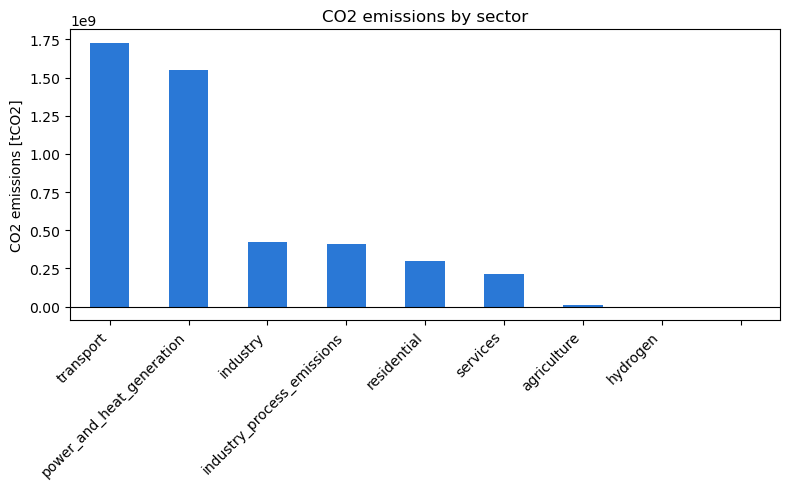

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
co2_by_sector.plot.bar(ax=ax, color="#2a78d6")

ax.set_ylabel("CO2 emissions [tCO2]")
ax.set_xlabel("")
ax.set_title("CO2 emissions by sector")
ax.axhline(0, color="black", linewidth=0.8)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# align reference (IEA) and model sectors on a common scale [MtCO2]
ref = df["Value"].rename(index=reference_map).reindex(reference_map.values())
ref.name = "Reference (IEA)"

# drops the other values
model = (co2_by_sector / 1e6).reindex(reference_map.values())
model.name = "Model (PyPSA)"

comparison = pd.concat([ref, model], axis=1)
comparison

,Reference (IEA),Model (PyPSA)
power_and_heat_generation,1524.902,1550.285047
transport,1507.915,1729.175379
industry,437.450,424.744299
residential,299.711,298.572548
services,211.222,213.988993
agriculture,36.288,8.763793


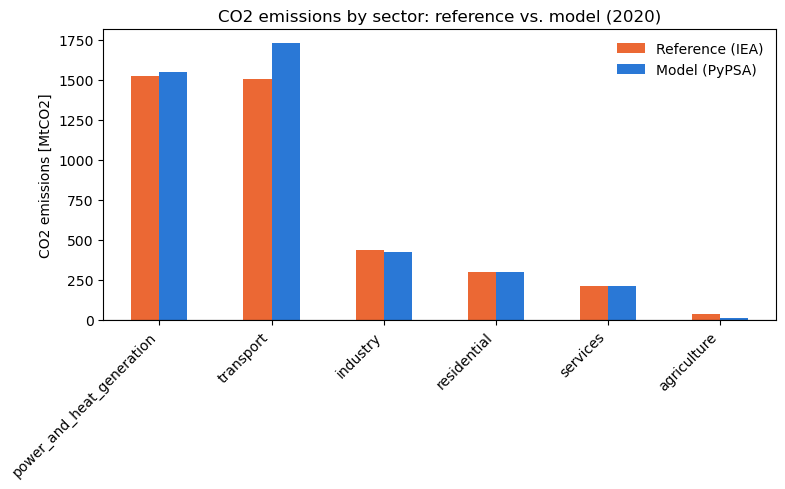

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

# validated categorical palette: slot 2 (reference) then slot 1 (model)
comparison.plot.bar(ax=ax, color=["#eb6834", "#2a78d6"])

ax.set_ylabel("CO2 emissions [MtCO2]")
ax.set_xlabel("")
ax.set_title("CO2 emissions by sector: reference vs. model (2020)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(frameon=False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# IEA values have a higher ag value for co2 emissions but also includes foresetry.

In [10]:
def fuel_use_by_sector(n, fuels=("coal", "oil", "gas")):
    "Fuel consumption [MWh] per sector, split by fuel type."
    comps = ["Load", "Link"]
    

    sector_from_carrier_prefix = {
        "residential": "residential",
        "services": "services",
        "agriculture": "agriculture",
        "industry": "industry",
        "land transport": "transport",
    }

    frames = []
    for fuel in fuels:
        s = n.statistics.withdrawal(
            comps=comps, bus_carrier=fuel, groupby=["sector", "carrier"]
        )
        s = s.reset_index()
        grouped = s.groupby("sector")["objective"].sum()
        grouped.name = fuel
        frames.append(grouped)

    return pd.concat(frames, axis=1).fillna(0).sort_index()


fuel_by_sector = fuel_use_by_sector(n1)
fuel_by_sector

,coal,oil,gas
sector,,,
,0.000000e+00,7.422723e+09,2.441030e+09
hydrogen,0.000000e+00,0.000000e+00,2.846994e+05
industry,0.000000e+00,0.000000e+00,1.592381e+09
power_and_heat_generation,2.952197e+09,5.877593e+05,2.817679e+09
residential,0.000000e+00,0.000000e+00,1.337599e+06
services,0.000000e+00,0.000000e+00,1.683601e+06


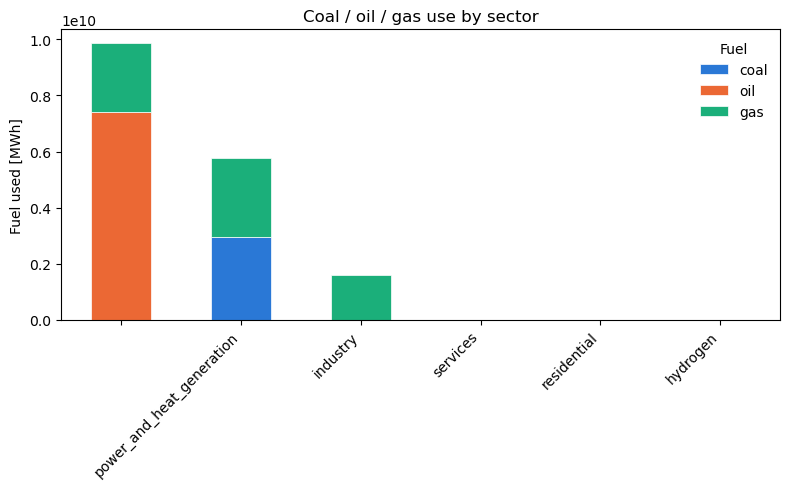

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

# fixed hue order (validated categorical palette, slots 1-3): coal, oil, gas
fuel_colors = {"coal": "#2a78d6", "oil": "#eb6834", "gas": "#1baf7a"}

fuel_by_sector.loc[fuel_by_sector.sum(axis=1).sort_values(ascending=False).index].plot.bar(
    ax=ax,
    stacked=True,
    color=[fuel_colors[f] for f in fuel_by_sector.columns],
    edgecolor="white",
    linewidth=0.5,
)

ax.set_ylabel("Fuel used [MWh]")
ax.set_xlabel("")
ax.set_title("Coal / oil / gas use by sector")
ax.legend(title="Fuel", frameon=False)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

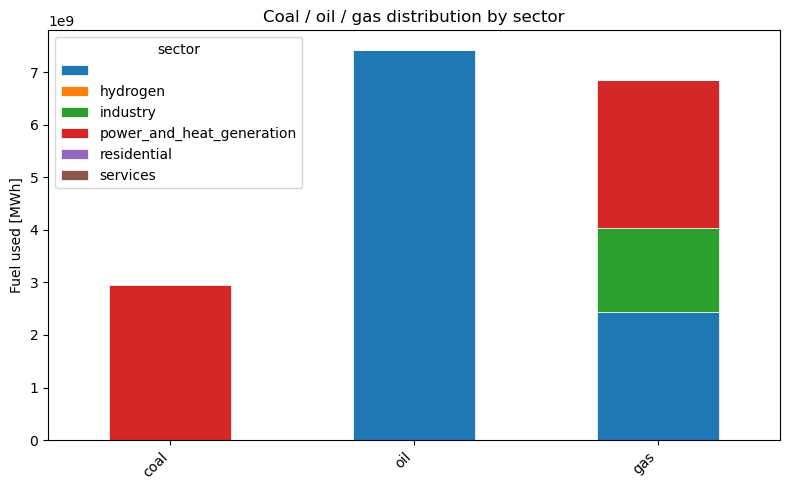

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

fuel_by_sector.T.plot.bar(
    ax=ax,
    stacked=True,
    edgecolor="white",
    linewidth=0.5,
)

ax.set_ylabel("Fuel used [MWh]")
ax.set_xlabel("")
ax.set_title("Coal / oil / gas distribution by sector")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
fuel_by_sector#.sum(axis=0)

,coal,oil,gas
sector,,,
,0.000000e+00,7.422723e+09,2.441030e+09
hydrogen,0.000000e+00,0.000000e+00,2.846994e+05
industry,0.000000e+00,0.000000e+00,1.592381e+09
power_and_heat_generation,2.952197e+09,5.877593e+05,2.817679e+09
residential,0.000000e+00,0.000000e+00,1.337599e+06
services,0.000000e+00,0.000000e+00,1.683601e+06
